In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import tensorflow as tf
import pandas as pd
import os

PROJECT_DIR = "/content/drive/MyDrive/SmartVisionAI"
MODEL_DIR = f"{PROJECT_DIR}/models"

results_df = pd.read_csv(f"{MODEL_DIR}/model_comparison_results.csv", index_col=0)
print(results_df)

best_model_name = results_df["Test Accuracy"].idxmax()
print("Best model:", best_model_name)

model_path = f"{MODEL_DIR}/{best_model_name}_smartvision.keras"
model = tf.keras.models.load_model(model_path)

with open(f"{MODEL_DIR}/class_names.txt", "r") as f:
    class_names = [line.strip() for line in f.readlines()]

IMG_SIZE = 224

print("Model loaded successfully.")
print("Classes:", class_names)

                Test Loss  Test Accuracy
EfficientNetB0   0.646596       0.813333
ResNet50         0.858393       0.754667
MobileNetV2      0.983172       0.709333
VGG16            1.849996       0.664000
Best model: EfficientNetB0
Model loaded successfully.
Classes: ['airplane', 'backpack', 'bear', 'bicycle', 'boat', 'bus', 'car', 'cat', 'cow', 'dog', 'elephant', 'giraffe', 'handbag', 'horse', 'motorcycle', 'person', 'sheep', 'sports_ball', 'suitcase', 'tie', 'traffic_light', 'train', 'truck', 'umbrella', 'zebra']


Saving CAR.jpg to CAR.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


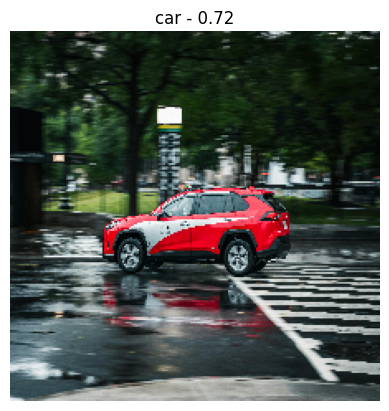

In [3]:
from google.colab import files
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()

for file_name in uploaded.keys():
    img = tf.keras.utils.load_img(file_name, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    predicted_index = np.argmax(prediction)
    confidence = np.max(prediction)

    predicted_class = class_names[predicted_index]

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{predicted_class} - {confidence:.2f}")
    plt.show()

STREAMLIT APP

In [4]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 59.5 MB/s eta 0:00:00


In [20]:
%%writefile app.py
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image
import pandas as pd
import os

st.set_page_config(page_title="SmartVision AI", layout="centered")

MODEL_DIR = "/content/drive/MyDrive/SmartVisionAI/models"
IMG_SIZE = 224

st.title("SmartVision AI")
st.subheader("Intelligent Multi-Class Object Recognition System")

@st.cache_resource
def load_class_names():
    with open(os.path.join(MODEL_DIR, "class_names.txt"), "r") as f:
        return [line.strip() for line in f.readlines()]

@st.cache_resource
def load_selected_model(model_name):
    model_path = os.path.join(MODEL_DIR, f"{model_name}_smartvision.keras")
    return tf.keras.models.load_model(model_path)

class_names = load_class_names()

available_models = [
    "MobileNetV2",
    "EfficientNetB0",
    "ResNet50",
    "VGG16"
]

model_name = st.sidebar.selectbox("Choose Model", available_models)

uploaded_file = st.file_uploader(
    "Upload image for prediction",
    type=["jpg", "jpeg", "png"]
)

def predict_image(model, image):
    image = image.convert("RGB")
    image = image.resize((IMG_SIZE, IMG_SIZE))

    img_array = tf.keras.utils.img_to_array(image)
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    predicted_index = np.argmax(prediction)
    confidence = float(np.max(prediction))

    top_indices = prediction[0].argsort()[-5:][::-1]

    top_predictions = []
    for idx in top_indices:
        top_predictions.append({
            "Class": class_names[idx],
            "Confidence (%)": round(float(prediction[0][idx]) * 100, 2)
        })

    return class_names[predicted_index], confidence, top_predictions

if uploaded_file is not None:
    image = Image.open(uploaded_file)
    st.image(image, caption="Uploaded Image", use_container_width=True)

    if st.button("Predict"):
        with st.spinner(f"Loading {model_name} model... Please wait."):
            model = load_selected_model(model_name)

        with st.spinner("Predicting..."):
            predicted_class, confidence, top_predictions = predict_image(model, image)

        st.success(f"Predicted Class: {predicted_class}")
        st.info(f"Confidence: {confidence * 100:.2f}%")

        df = pd.DataFrame(top_predictions)
        st.subheader("Top 5 Predictions")
        st.dataframe(df, use_container_width=True)
        st.bar_chart(df.set_index("Class")["Confidence (%)"])
else:
    st.info("Upload an image to start prediction.")

Overwriting app.py


In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
!pkill -f streamlit
!pkill -f localtunnel

In [23]:
!streamlit run app.py --server.port 8501 --server.address 0.0.0.0 --server.enableCORS false --server.enableXsrfProtection false > streamlit.log 2>&1 &

In [24]:
from google.colab import output
print(output.eval_js("google.colab.kernel.proxyPort(8501)"))

https://8501-m-s-kkb-euw4b0-2xq1ni6gct3lj-b.europe-west4-0.prod.colab.dev
